# WholeBrain Comparison Plots

This notebook adapts the plotting utilities from the WholeBrain repository to the `neuroscience_control` comparison workflow.

It focuses on three plot families that map well to this repo's outputs:

- FC matrices with `WholeBrain.Utils.Plotting.plotSC`
- FCD and phase-FCD matrices using the same WholeBrain matrix plotting helper
- cortical maps of node-wise FC error with `WholeBrain.Utils.Plotting.plot3DBrain.plotColorView`

The defaults are tuned for the `ts_young` dataset because it uses 100 ROIs, which matches the Schaefer surface adapter used below.
        


In [1]:
import io
import os
import sys
import subprocess
from contextlib import redirect_stdout
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from nilearn import datasets, surface

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'examples':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
        


In [2]:
WHOLEBRAIN_URL = 'https://github.com/dagush/WholeBrain.git'
WHOLEBRAIN_DIR = PROJECT_ROOT / '.cache' / 'WholeBrain'

if not WHOLEBRAIN_DIR.exists():
    WHOLEBRAIN_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ['git', 'clone', '--depth', '1', WHOLEBRAIN_URL, str(WHOLEBRAIN_DIR)],
        check=True,
    )

if str(WHOLEBRAIN_DIR) not in sys.path:
    sys.path.insert(0, str(WHOLEBRAIN_DIR))

from WholeBrain.Utils.Plotting import plotSC
from WholeBrain.Utils.Plotting.plot3DBrain import plotColorView

wholebrain_commit = subprocess.check_output(
    ['git', '-C', str(WHOLEBRAIN_DIR), 'rev-parse', '--short', 'HEAD'],
    text=True,
).strip()

print(f'WholeBrain repo: {WHOLEBRAIN_DIR}')
print(f'WholeBrain commit: {wholebrain_commit}')
        


WholeBrain repo: /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/.cache/WholeBrain
WholeBrain commit: 0acef9b


## Configuration

The defaults keep runtime reasonable on CPU while still producing the WholeBrain-style panels. Increase `MAX_PATHS` or `N_TIMEPOINTS` if you want a heavier comparison.
        


In [13]:
DATASET_TYPE = 'ts_young'
DATA_PATH = 'data/ts_young/ts_young_TR0.72.mat'
LSD_DATA_DIR = 'data/lsd'
CHECKPOINT_DIR = 'checkpoints'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

N_TIMEPOINTS = 120
MAX_PATHS = 2
FCD_WIN_LEN = 30
FCD_WIN_STEP = 5
SURFACE_TOP_K = 3
MODEL_FILTER = None  # e.g. {'Hopf (Grid)', 'Hybrid Hopf', 'Neural SDE'}

SAVE_DIR = PROJECT_ROOT / 'paper' / 'images' / 'wholebrain'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')
print(f'Figures will be saved in: {SAVE_DIR}')
        


Device: cpu
Figures will be saved in: /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain


In [4]:
from src.dataset import create_data_loaders, load_dataset
from src.training import HopfConfig

cfg = HopfConfig()
cfg.dataset_type = DATASET_TYPE
cfg.data_path = DATA_PATH
cfg.lsd_data_dir = LSD_DATA_DIR
cfg.use_wandb = False
cfg.dt_min = 0.05

dataset = load_dataset(cfg, DEVICE)
window_size = min(N_TIMEPOINTS, dataset.n_timepoints // 2)

_, _, _, test_intra_loader = create_data_loaders(
    dataset=dataset,
    window_size=window_size,
    batch_size=cfg.batch_size,
    n_windows_per_epoch=cfg.n_windows_per_epoch,
    train_ratio=cfg.train_ratio,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
    device=DEVICE,
)

batch = next(iter(test_intra_loader))
if len(batch) == 4:
    ts_target, _, patient_ids, control = batch
elif len(batch) == 3:
    ts_target, _, patient_ids = batch
    control = None
else:
    raise ValueError(f'Unexpected batch structure: {len(batch)} items')

ts_target = ts_target[:MAX_PATHS, :, :N_TIMEPOINTS]
if control is not None:
    control = control[:MAX_PATHS]
initial_state = ts_target[:, :, 0]

print(f'dataset_type   : {DATASET_TYPE}')
print(f'n_subjects     : {dataset.timeseries.shape[0]}')
print(f'n_rois         : {dataset.n_rois}')
print(f'n_timepoints   : {dataset.n_timepoints}')
print(f'window_size    : {window_size}')
print(f'target batch   : {tuple(ts_target.shape)}')
print(f'control shape  : {None if control is None else tuple(control.shape)}')
        


Loaded dataset:
  - subjects=94  ROIs=100  T=1200
  - FC shape=torch.Size([100, 100])  dtype=torch.complex64  dt=0.72s
  - control_dims=0
dataset_type   : ts_young
n_subjects     : 94
n_rois         : 100
n_timepoints   : 1200
window_size    : 120
target batch   : (2, 100, 120)
control shape  : (2, 0)


In [5]:
from src.models import load_model_from_checkpoint

_MODEL_TAGS = [
    ('gnn_hopf', 'GNN Hopf'),
    ('hybrid_neural', 'Hybrid+Neural'),
    ('hybrid_hopf', 'Hybrid Hopf'),
    ('nsde', 'Neural SDE'),
    ('hopf', 'Hopf'),
]


def short_label(stem: str) -> str:
    lower = stem.lower()
    for tag, label in _MODEL_TAGS:
        if tag in lower:
            return label + (' (Grid)' if 'grid' in lower else '')
    return stem


models = {}
for ckpt_path in sorted(Path(CHECKPOINT_DIR).glob(f'*{DATASET_TYPE}*.pt')):
    model, model_type, _ = load_model_from_checkpoint(str(ckpt_path), device=DEVICE)
    label = short_label(ckpt_path.stem)
    if model.n_rois != dataset.n_rois:
        print(f'Skipping {ckpt_path.name}: ROI mismatch ({model.n_rois} != {dataset.n_rois})')
        continue
    if MODEL_FILTER is not None and label not in MODEL_FILTER:
        continue
    models[label] = model
    print(f'Loaded {label:16s} ({model_type})')

if not models:
    raise RuntimeError('No compatible checkpoints were loaded. Adjust MODEL_FILTER or CHECKPOINT_DIR.')

print(f'Loaded {len(models)} model(s).')
        


Loaded GNN Hopf         (GNNHopfModel)
Loaded Hopf             (CoupledHopfModel)
Loaded Hopf (Grid)      (CoupledHopfModel)
Loaded Hybrid Hopf      (HybridHopfModel)
Loaded Hybrid+Neural    (HybridHopfNeuralModel)
Loaded Neural SDE       (NeuralSDE)
Loaded 6 model(s).


In [6]:
from src.metrics import compute_static_fc, fisher_batch_average
from src.metrics.dynamics_metrics import fcd_matrix, phfcd_matrix


def fc_average(ts: torch.Tensor) -> np.ndarray:
    return fisher_batch_average(compute_static_fc(ts)).detach().cpu().numpy()


def upper_triangle_corr(a: np.ndarray, b: np.ndarray) -> float:
    idx = np.triu_indices_from(a, k=1)
    return float(np.corrcoef(a[idx], b[idx])[0, 1])


def upper_triangle_mse(a: np.ndarray, b: np.ndarray) -> float:
    idx = np.triu_indices_from(a, k=1)
    return float(np.mean((a[idx] - b[idx]) ** 2))


def forward_kwargs_for(model) -> dict:
    kwargs = {'n_steps': N_TIMEPOINTS}
    if control is not None and getattr(model, 'n_control_dims', 0) > 0 and control.shape[-1] > 0:
        kwargs['control'] = control
    return kwargs


def subject_real_and_phase(ts: torch.Tensor, subject_index: int = 0):
    subject_ts = ts[subject_index]
    return subject_ts.real.T, torch.angle(subject_ts).T


ts_preds = {}
for name, model in models.items():
    with torch.no_grad():
        ts_preds[name] = model.forward(initial_state=initial_state, **forward_kwargs_for(model)).cpu()
    print(f'{name:16s} -> {tuple(ts_preds[name].shape)}')

fc_target = fc_average(ts_target)
target_real, target_phase = subject_real_and_phase(ts_target, subject_index=0)
target_fcd = fcd_matrix(target_real, FCD_WIN_LEN, FCD_WIN_STEP)
target_phfcd = phfcd_matrix(target_phase)

fcd_target_np = None if target_fcd is None else target_fcd.detach().cpu().numpy()
phfcd_target_np = None if target_phfcd is None else target_phfcd.detach().cpu().numpy()

summary_rows = []
summary_by_name = {}
fc_by_model = {}
fcd_by_model = {}
phfcd_by_model = {}

for name, ts_pred in ts_preds.items():
    fc_pred = fc_average(ts_pred)
    fc_by_model[name] = fc_pred

    pred_real, pred_phase = subject_real_and_phase(ts_pred, subject_index=0)
    pred_fcd = fcd_matrix(pred_real, FCD_WIN_LEN, FCD_WIN_STEP)
    pred_phfcd = phfcd_matrix(pred_phase)

    fcd_by_model[name] = None if pred_fcd is None else pred_fcd.detach().cpu().numpy()
    phfcd_by_model[name] = None if pred_phfcd is None else pred_phfcd.detach().cpu().numpy()

    row = {
        'name': name,
        'fc_corr': upper_triangle_corr(fc_pred, fc_target),
        'fc_mse': upper_triangle_mse(fc_pred, fc_target),
        'node_error_mean': float(np.abs(fc_pred - fc_target).mean(axis=1).mean()),
        'fcd_corr': np.nan,
        'phfcd_corr': np.nan,
    }
    if fcd_target_np is not None and fcd_by_model[name] is not None:
        row['fcd_corr'] = upper_triangle_corr(fcd_by_model[name], fcd_target_np)
    if phfcd_target_np is not None and phfcd_by_model[name] is not None:
        row['phfcd_corr'] = upper_triangle_corr(phfcd_by_model[name], phfcd_target_np)
    summary_rows.append(row)

summary_rows = sorted(summary_rows, key=lambda row: row['fc_corr'], reverse=True)
summary_by_name = {row['name']: row for row in summary_rows}

for row in summary_rows:
    print(
        f"{row['name']:16s}  "
        f"FC r={row['fc_corr']:.3f}  "
        f"FC mse={row['fc_mse']:.4f}  "
        f"FCD r={row['fcd_corr']:.3f}  "
        f"phFCD r={row['phfcd_corr']:.3f}"
    )
        


GNN Hopf         -> (2, 100, 120)
Hopf             -> (2, 100, 120)
Hopf (Grid)      -> (2, 100, 120)
Hybrid Hopf      -> (2, 100, 120)
Hybrid+Neural    -> (2, 100, 120)
Neural SDE       -> (2, 100, 120)
Neural SDE        FC r=0.535  FC mse=0.0772  FCD r=0.828  phFCD r=0.755
GNN Hopf          FC r=0.476  FC mse=0.0752  FCD r=0.904  phFCD r=0.680
Hybrid+Neural     FC r=0.454  FC mse=0.0977  FCD r=0.773  phFCD r=0.412
Hybrid Hopf       FC r=0.427  FC mse=0.0707  FCD r=0.860  phFCD r=0.687
Hopf (Grid)       FC r=0.163  FC mse=0.0799  FCD r=0.883  phFCD r=0.388
Hopf              FC r=0.154  FC mse=0.0639  FCD r=0.903  phFCD r=0.742


## WholeBrain Matrix Panels

`plotSC.plotSC` is the simplest WholeBrain plotting primitive for our use case, so the helper below uses it to assemble reusable multi-panel figures with shared color limits.
        


In [15]:
def plot_wholebrain_matrix_panel(items, *, title, cmap, clim=None, ncols=4, save_path=None):
    n_items = len(items)
    ncols = min(ncols, n_items)
    nrows = int(np.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (label, matrix) in zip(axes, items):
        with redirect_stdout(io.StringIO()):
            plotSC.plotSC(ax, np.asarray(matrix), label, labelAxis='none', colormap=cmap, fontSize=10)
        if clim is not None and ax.images:
            ax.images[0].set_clim(*clim)

    for ax in axes[n_items:]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14, y=0.98)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved {save_path}')

    return fig
        


Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_fc_panel.png
Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_fc_residuals.png


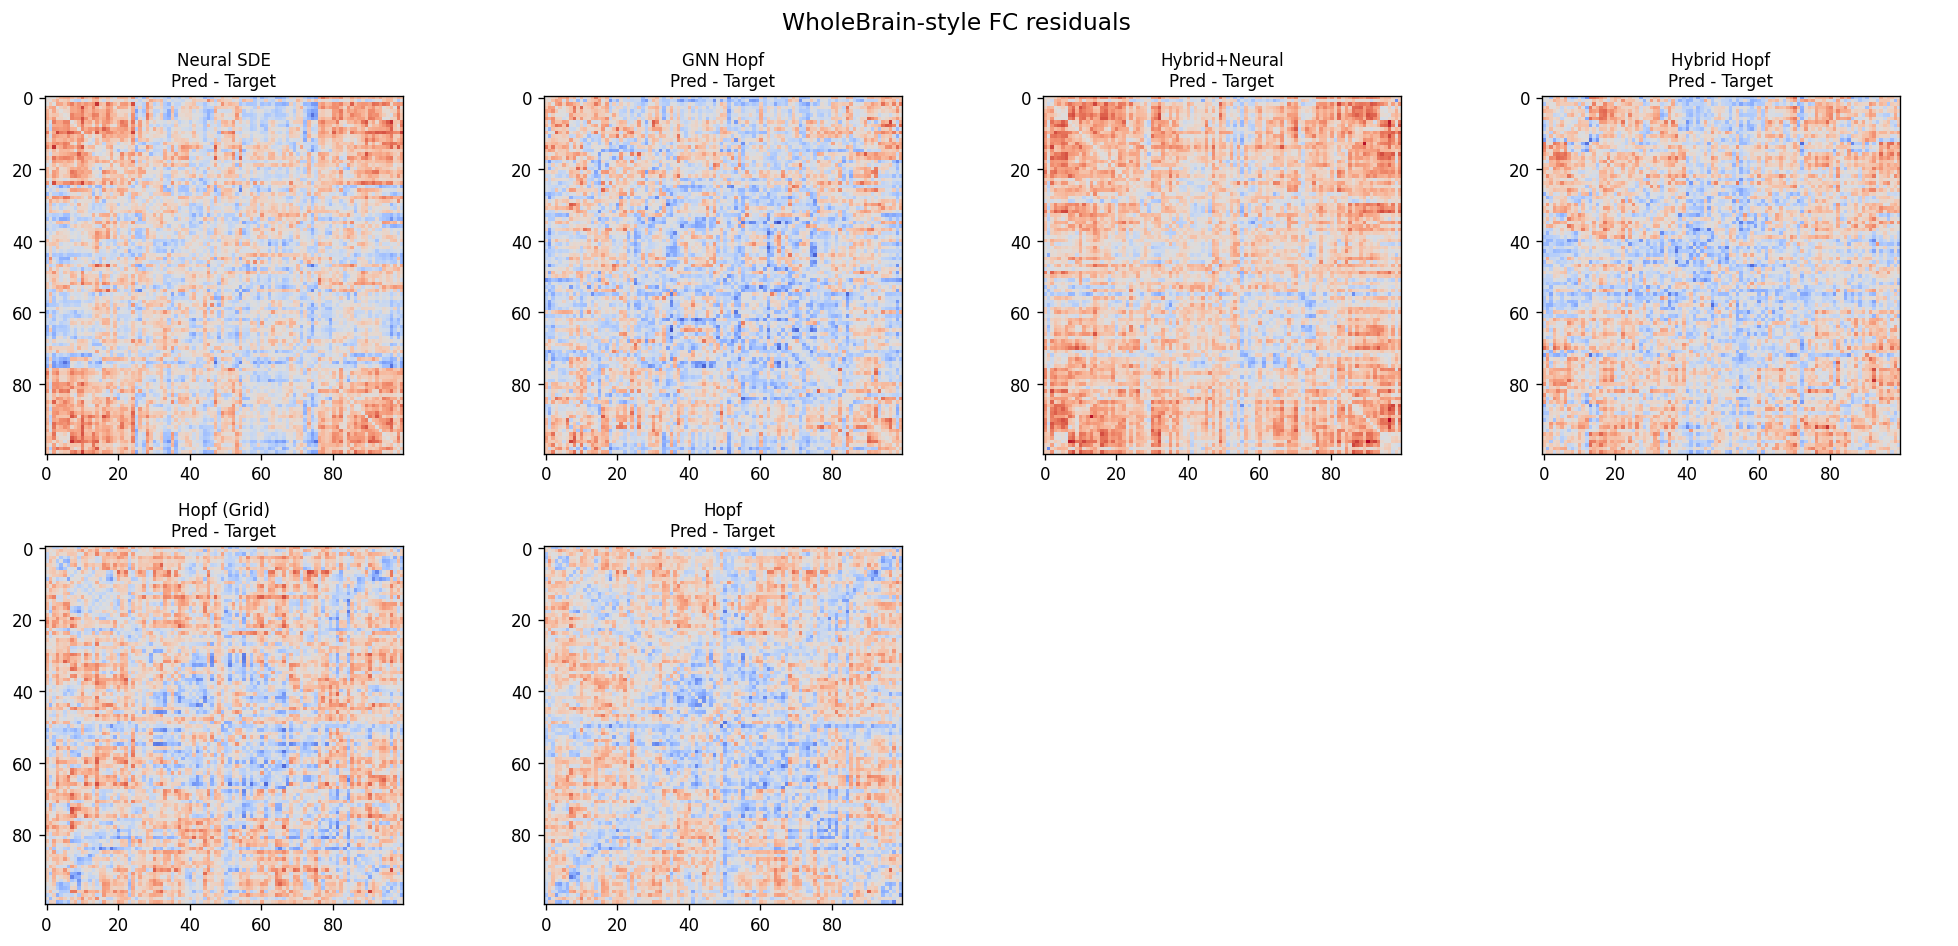

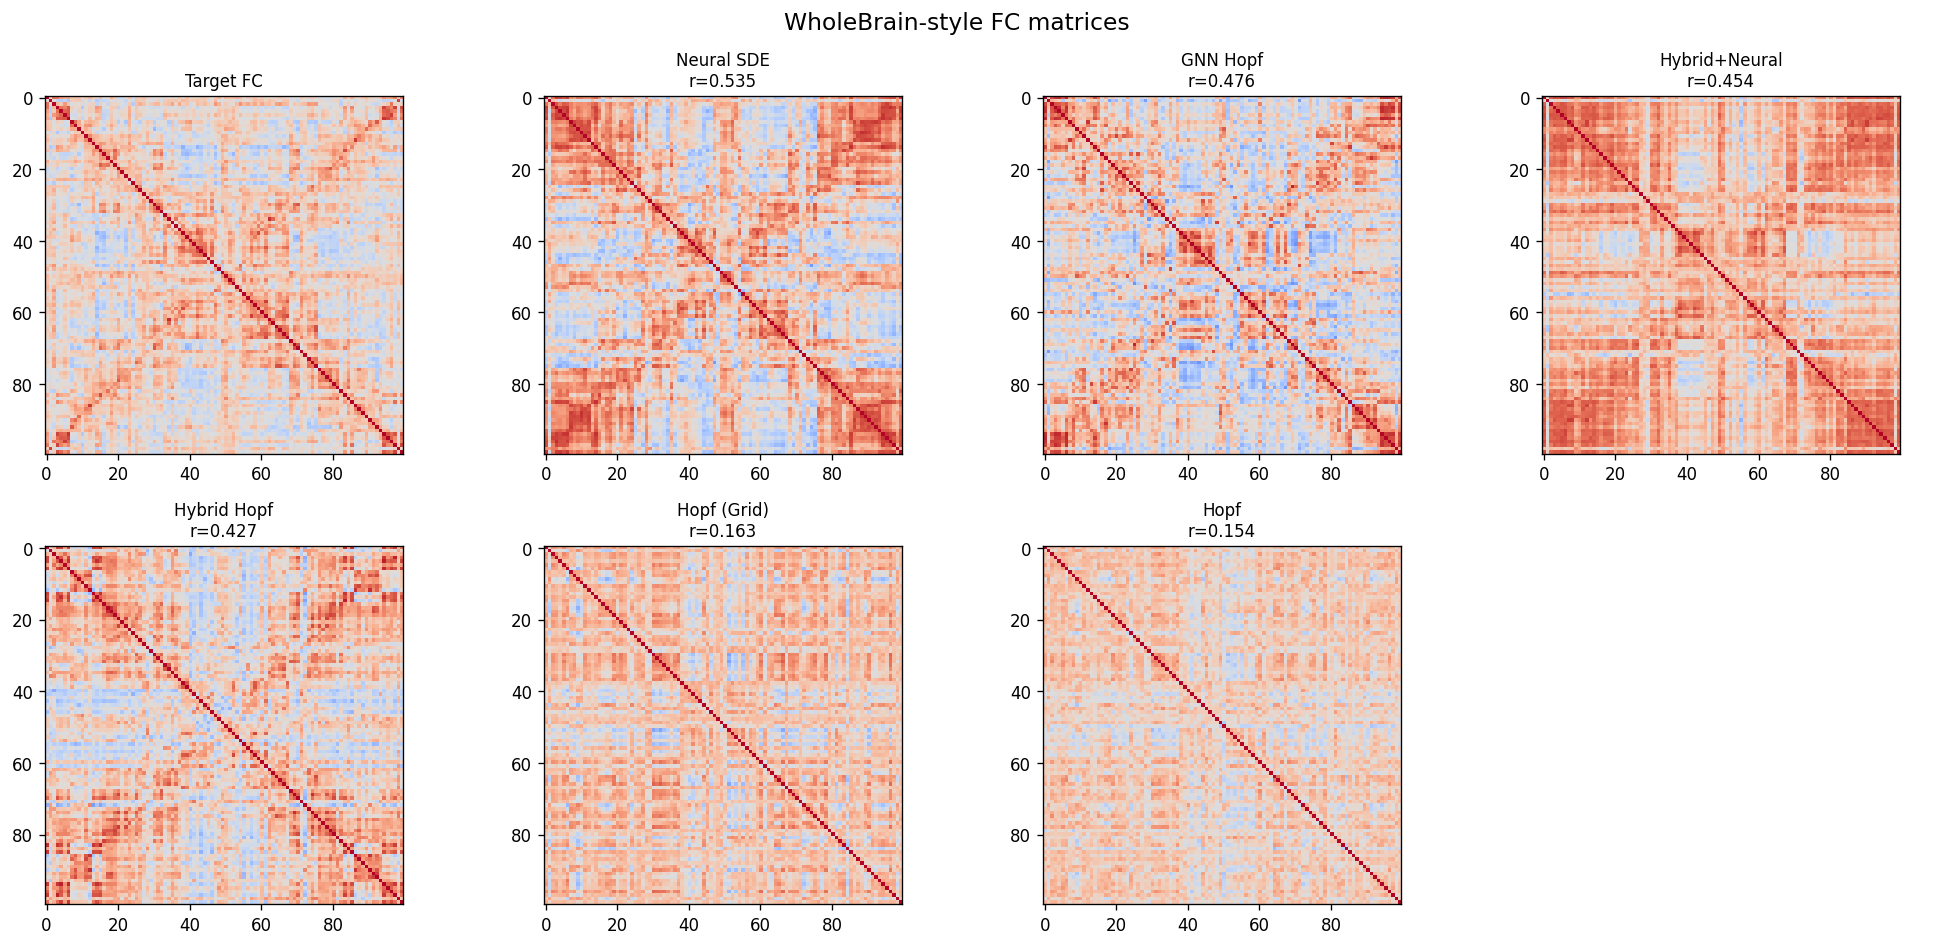

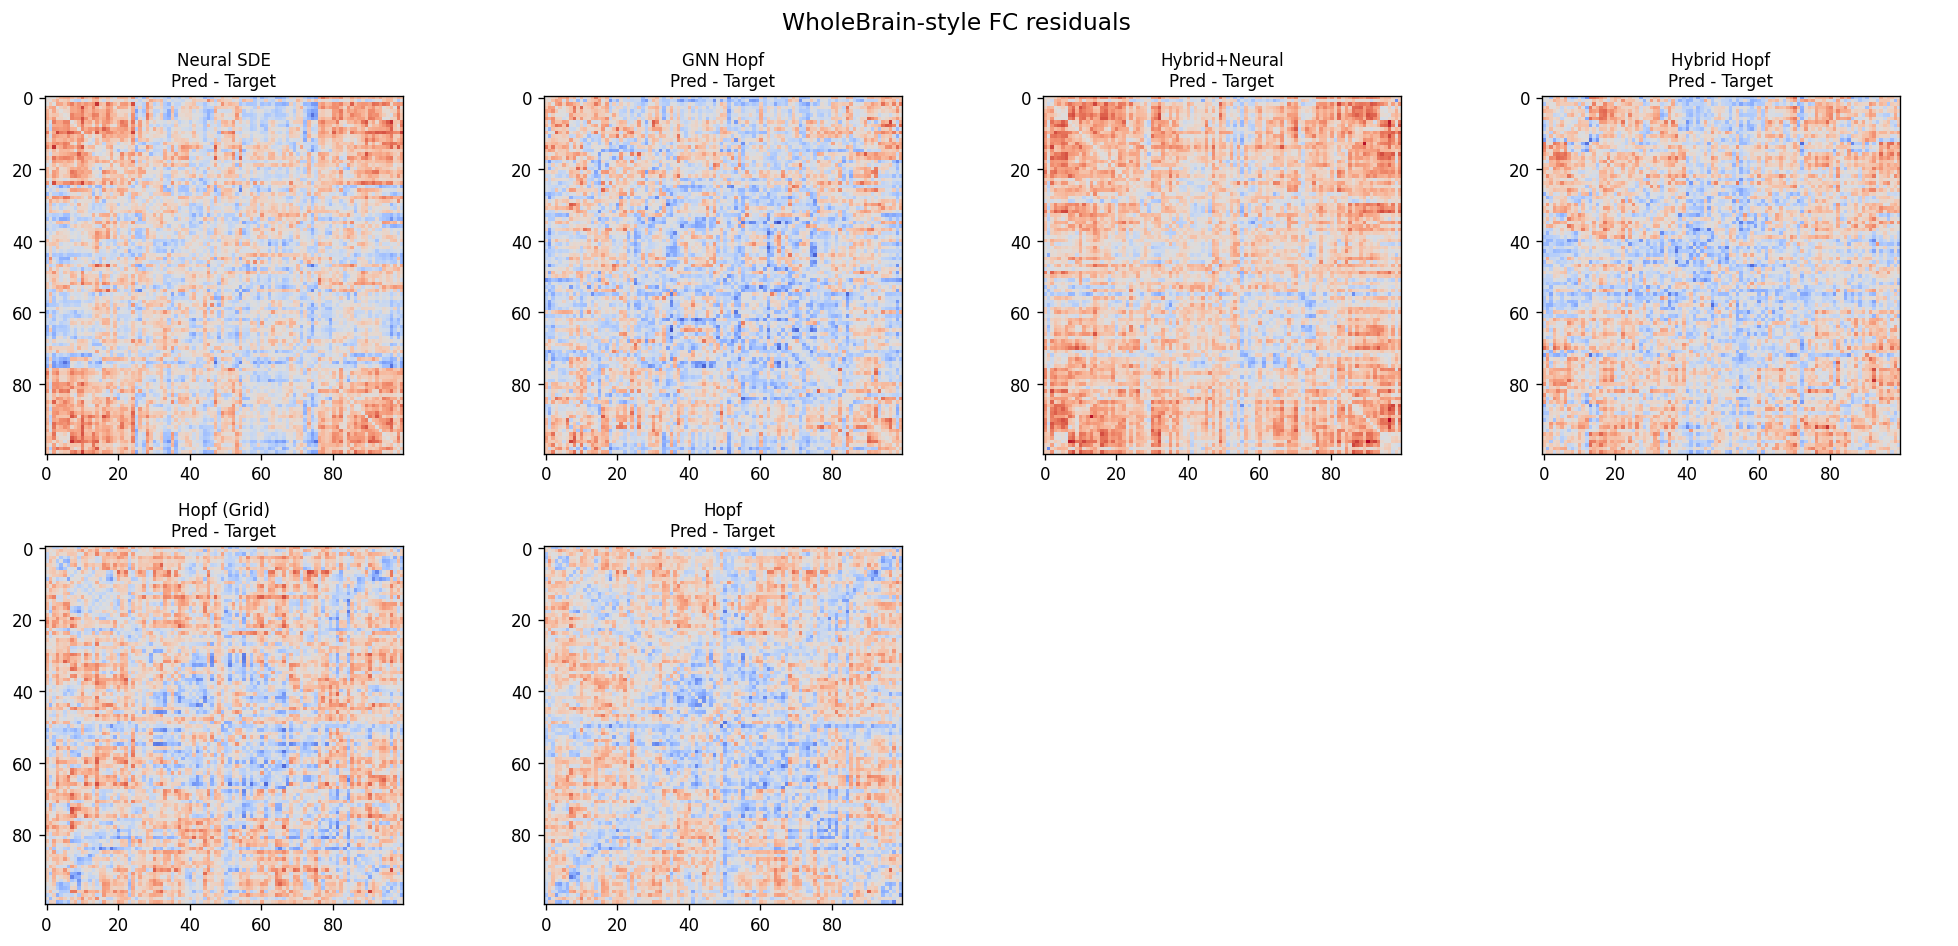

In [16]:
fc_items = [('Target FC', fc_target)] + [
    (f"{row['name']}\nr={row['fc_corr']:.3f}", fc_by_model[row['name']])
    for row in summary_rows
]

plot_wholebrain_matrix_panel(
    fc_items,
    title='WholeBrain-style FC matrices',
    cmap='coolwarm',
    clim=(-1.0, 1.0),
    ncols=4,
    save_path=SAVE_DIR / 'wholebrain_fc_panel.png',
)

delta_limit = max(
    float(np.max(np.abs(fc_by_model[name] - fc_target)))
    for name in fc_by_model
)
delta_items = [
    (f"{row['name']}\nPred - Target", fc_by_model[row['name']] - fc_target)
    for row in summary_rows
]

plot_wholebrain_matrix_panel(
    delta_items,
    title='WholeBrain-style FC residuals',
    cmap='coolwarm',
    clim=(-delta_limit, delta_limit),
    ncols=4,
    save_path=SAVE_DIR / 'wholebrain_fc_residuals.png',
)


## WholeBrain Dynamics Panels

FCD and phase-FCD are computed from the first empirical trajectory in the selected batch and then rendered with the same WholeBrain matrix utility.
        


array([{'name': 'Neural SDE', 'fc_corr': 0.5354711443460477, 'fc_mse': 0.07717495411634445, 'node_error_mean': 0.21802103519439697, 'fcd_corr': 0.8280117498707169, 'phfcd_corr': 0.7546122840937951},
       {'name': 'GNN Hopf', 'fc_corr': 0.4755615364360229, 'fc_mse': 0.07523136585950851, 'node_error_mean': 0.21722982823848724, 'fcd_corr': 0.9035434734931538, 'phfcd_corr': 0.6797815629051913},
       {'name': 'Hybrid Hopf', 'fc_corr': 0.4265644185579145, 'fc_mse': 0.07071484625339508, 'node_error_mean': 0.21213121712207794, 'fcd_corr': 0.8601571602426693, 'phfcd_corr': 0.6874588078855851}],
      dtype=object)

Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_fcd_panel.png
Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_phfcd_panel.png


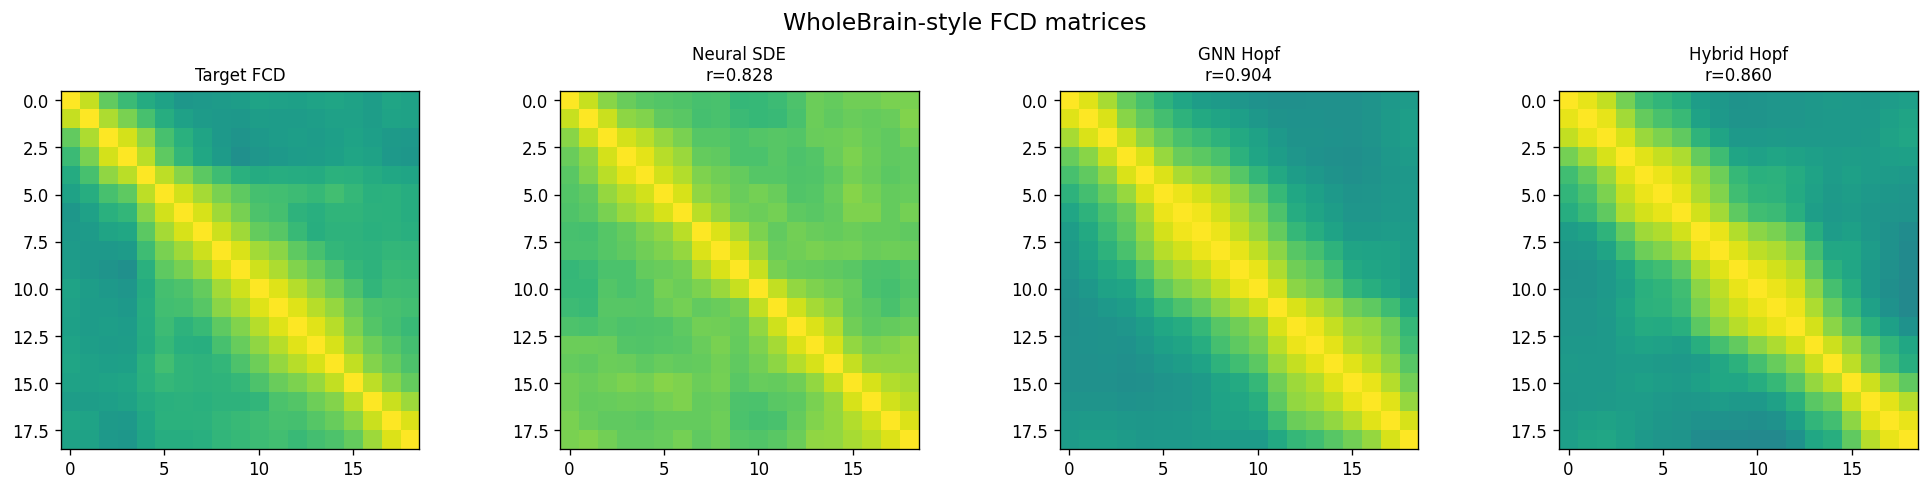

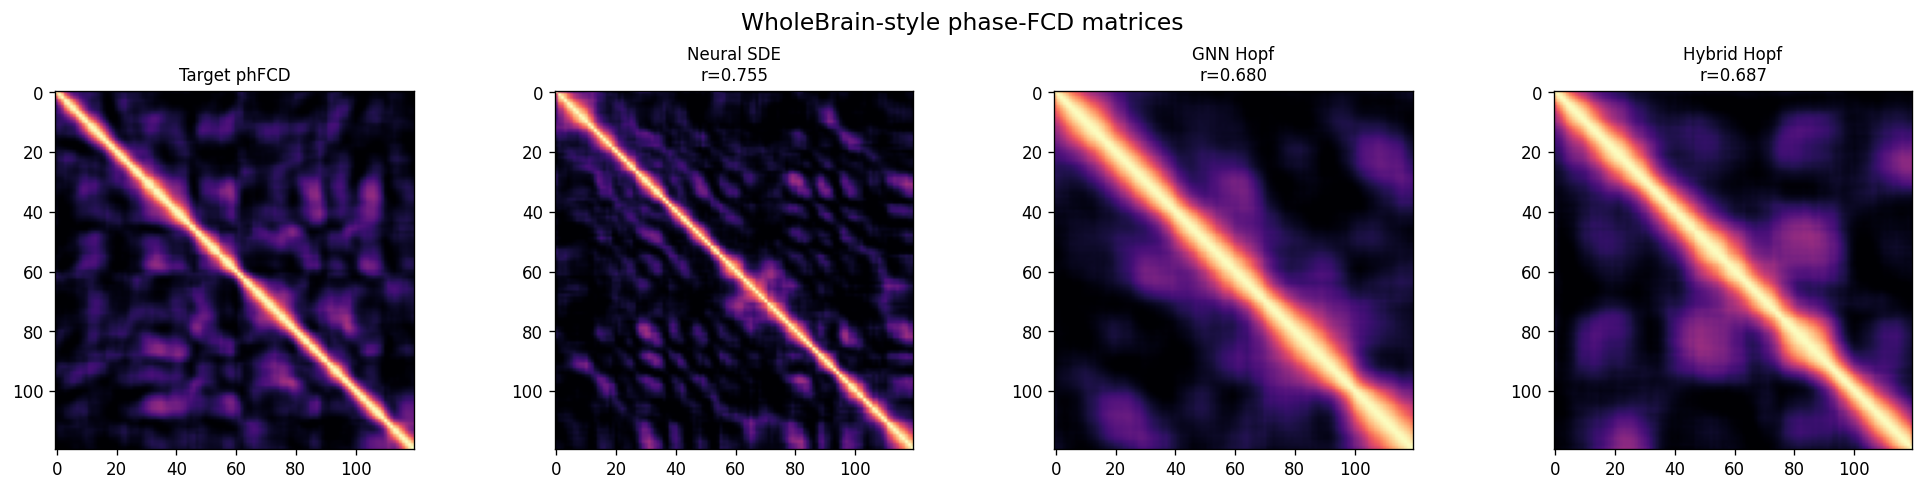

In [57]:
top_dynamic = [row['name'] for row in np.array(summary_rows)[[0,1,3]]]

if fcd_target_np is None:
    print('Skipping FCD plots because the selected window is too short for the configured sliding window.')
else:
    fcd_items = [('Target FCD', fcd_target_np)] + [
        (f"{name}\nr={summary_by_name[name]['fcd_corr']:.3f}", fcd_by_model[name])
        for name in top_dynamic
    ]
    plot_wholebrain_matrix_panel(
        fcd_items,
        title='WholeBrain-style FCD matrices',
        cmap='viridis',
        clim=(-1.0, 1.0),
        ncols=4,
        save_path=SAVE_DIR / 'wholebrain_fcd_panel.png',
    )

if phfcd_target_np is None:
    print('Skipping phFCD plots because phase-FCD could not be computed for this selection.')
else:
    phfcd_items = [('Target phFCD', phfcd_target_np)] + [
        (f"{name}\nr={summary_by_name[name]['phfcd_corr']:.3f}", phfcd_by_model[name])
        for name in top_dynamic
    ]
    plot_wholebrain_matrix_panel(
        phfcd_items,
        title='WholeBrain-style phase-FCD matrices',
        cmap='magma',
        clim=(0.0, 1.0),
        ncols=4,
        save_path=SAVE_DIR / 'wholebrain_phfcd_panel.png',
    )


## WholeBrain Timestep Surface Adapter

WholeBrain's cortical plotting code expects surface meshes plus a parcel-to-vertex map. For `ts_young` we can build that map from the Schaefer atlas and then plot activity snapshots across several timesteps using only left and right lateral views.


In [60]:
SUPPORTED_SURFACE_ROIS = set(range(100, 1001, 100))


@lru_cache(maxsize=12)
def build_schaefer_cortex(
    n_rois: int,
    mesh: str = 'fsaverage5',
    surface_kind: str = 'pial',
):
    if n_rois not in SUPPORTED_SURFACE_ROIS:
        raise ValueError(
            f'Surface plots currently expect Schaefer parcels in {sorted(SUPPORTED_SURFACE_ROIS)}; got {n_rois}.'
        )

    surface_files = {
        'infl': ('infl_left', 'infl_right'),
        'pial': ('pial_left', 'pial_right'),
        'white': ('white_left', 'white_right'),
    }
    if surface_kind not in surface_files:
        raise ValueError(f"surface_kind must be one of {sorted(surface_files)}, got {surface_kind!r}.")

    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=7,
        resolution_mm=2,
    )
    labels_img = nib.load(atlas['maps'])
    fsaverage = datasets.fetch_surf_fsaverage(mesh=mesh)

    labels_left = np.rint(
        surface.vol_to_surf(
            labels_img,
            fsaverage.pial_left,
            interpolation='nearest_most_frequent',
        )
    ).astype(int) - 1
    labels_right = np.rint(
        surface.vol_to_surf(
            labels_img,
            fsaverage.pial_right,
            interpolation='nearest_most_frequent',
        )
    ).astype(int) - 1

    surface_left_key, surface_right_key = surface_files[surface_kind]

    return {
        'model_L': nib.load(getattr(fsaverage, surface_left_key)),
        'model_R': nib.load(getattr(fsaverage, surface_right_key)),
        'map_L': labels_left,
        'map_R': labels_right,
    }


def prepare_roi_activity(array_like, *, n_rois: int, subject_index: int = 0, complex_mode: str = 'real'):
    arr = array_like.detach().cpu().numpy() if torch.is_tensor(array_like) else np.asarray(array_like)

    if arr.ndim == 3:
        arr = arr.mean(axis=0) if subject_index is None else arr[int(subject_index)]
    elif arr.ndim != 2:
        raise ValueError(f'Expected a 2-D or 3-D array, got shape {arr.shape}.')

    if np.iscomplexobj(arr):
        if complex_mode == 'real':
            arr = arr.real
        elif complex_mode == 'imag':
            arr = arr.imag
        elif complex_mode == 'abs':
            arr = np.abs(arr)
        else:
            raise ValueError("complex_mode must be one of: 'real', 'imag', 'abs'.")

    arr = np.asarray(arr, dtype=float)
    if arr.shape[0] != n_rois and arr.shape[1] == n_rois:
        arr = arr.T

    if arr.shape[0] != n_rois:
        raise ValueError(f'Could not align timeseries with n_rois={n_rois}. Final shape was {arr.shape}.')

    return arr


def positive_zscore_activity(series: np.ndarray) -> np.ndarray:
    centered = series - np.nanmean(series)
    scale = np.nanstd(centered)
    zscore = centered / (scale + 1e-6)
    return np.clip(zscore, 0.0, None)


def plot_timestep_lateral_rows(
    series_by_name,
    time_indices,
    *,
    subject_index: int = 0,
    complex_mode: str = 'real',
    cmap_name: str = 'magma',
    scale_percentile: float = 99.0,
    surface_mesh: str = 'fsaverage5',
    surface_kind: str = 'pial',
    render_mode: str = 'gouraud',
    shadowed: bool = True,
    lighting_bias: float = 0.15,
    title: str = 'WholeBrain lateral activity across timesteps',
    time_labels=None,
    save_path=None,
):
    row_names = list(series_by_name)
    if not row_names:
        raise ValueError('series_by_name must not be empty.')

    cortex = build_schaefer_cortex(
        dataset.n_rois,
        mesh=surface_mesh,
        surface_kind=surface_kind,
    )
    prepared = {
        name: positive_zscore_activity(
            prepare_roi_activity(
                series,
                n_rois=dataset.n_rois,
                subject_index=subject_index,
                complex_mode=complex_mode,
            )
        )
        for name, series in series_by_name.items()
    }

    time_indices = list(dict.fromkeys(int(t) for t in time_indices))
    if not time_indices:
        raise ValueError('time_indices must contain at least one timestep.')

    all_values = np.concatenate([series[:, time_indices].ravel() for series in prepared.values()])
    positive_values = all_values[all_values > 0]
    vmax = np.percentile(positive_values, scale_percentile) if positive_values.size else 1.0
    vmax = max(float(vmax), 1e-3)

    n_rows = len(row_names)
    n_cols = len(time_indices)
    fig, axes = plt.subplots(n_rows, 2 * n_cols, figsize=(2.3 * 2 * n_cols, 2. * n_rows))
    axes = np.atleast_2d(axes)

    # cmap = plt.get_cmap(cmap_name)

    import matplotlib.colors as mcolors
    base_cmap = plt.get_cmap('magma')
    colors = base_cmap(np.linspace(0, 1, 256))
    colors[0] = mcolors.to_rgba('lightgrey')  # Set the first epsilon value to light grey
    cmap = mcolors.ListedColormap(colors)
    norm = Normalize(vmin=0.0, vmax=vmax)

    for row_idx, name in enumerate(row_names):
        series = prepared[name]

        axes[row_idx, 0].text(
            -0.28,
            0.5,
            name,
            transform=axes[row_idx, 0].transAxes,
            ha='right',
            va='center',
            fontsize=10,
            fontweight='bold',
        )

        for col_idx, t_idx in enumerate(time_indices):
            roi_values = series[:, t_idx]
            data = {'func_L': roi_values, 'func_R': roi_values}

            left_ax = axes[row_idx, 2 * col_idx]
            right_ax = axes[row_idx, 2 * col_idx + 1]
            plotColorView(
                left_ax,
                cortex,
                data,
                dataset.n_rois,
                'Lh-lateral',
                cmap=cmap,
                norm=norm,
                mode=render_mode,
                shadowed=shadowed,
                lightingBias=lighting_bias,
            )
            plotColorView(
                right_ax,
                cortex,
                data,
                dataset.n_rois,
                'Rh-lateral',
                cmap=cmap,
                norm=norm,
                mode=render_mode,
                shadowed=shadowed,
                lightingBias=lighting_bias,
            )

            if row_idx == 0:
                label = time_labels[col_idx] if time_labels is not None else f't={t_idx * dataset.dt:.2f}s'
                left_ax.set_title(f'{label} L', fontsize=9)
                right_ax.set_title(f'{label} R', fontsize=9)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    # Adjust layout first
    fig.suptitle(title, fontsize=14, y=0.995)
    fig.subplots_adjust(left=0.08, right=0.96, bottom=0.08, top=0.90, wspace=0.02, hspace=0.18)
    fig.colorbar(
        sm,
        ax=axes.ravel().tolist(),
        fraction=0.046, 
        pad=0.04,  # Increase this to push it further right
        label='Positive z-scored activity',
    )

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved {save_path}')

    return fig


Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_timestep_lateral_magma.pdf


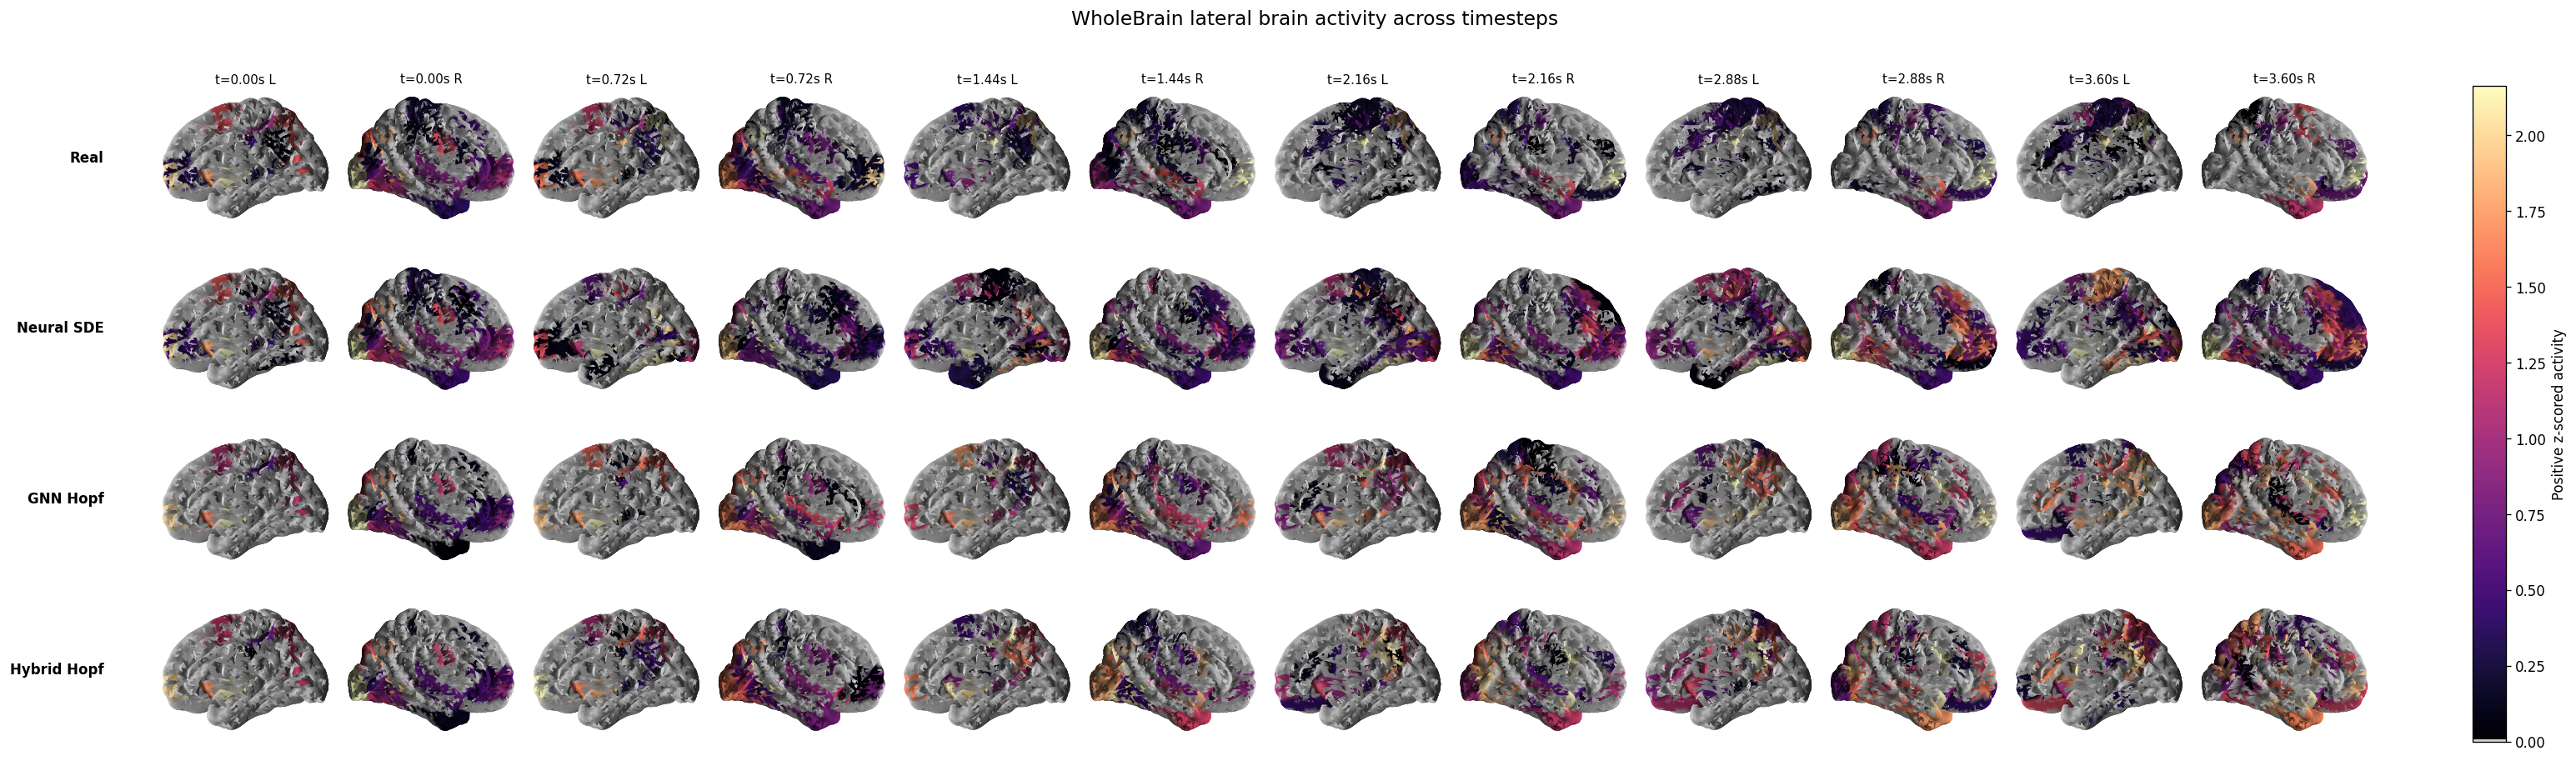

In [62]:
if dataset.n_rois not in SUPPORTED_SURFACE_ROIS:
    print(
        f'Skipping surface plots because n_rois={dataset.n_rois} is not a supported Schaefer parcellation size.'
    )
else:
    brain_rows = {'Real': ts_target}
    for row in np.array(summary_rows)[[0,1,3]]: #summary_rows[: min(SURFACE_TOP_K, len(summary_rows))]:
        brain_rows[row['name']] = ts_preds[row['name']]

    BRAIN_TIMESTEP_SUBJECT = 0
    BRAIN_TIMESTEP_COLUMNS = min(6, N_TIMEPOINTS)
    BRAIN_TIMESTEP_INDICES = np.unique(
        np.linspace(0, BRAIN_TIMESTEP_COLUMNS - 1, num=BRAIN_TIMESTEP_COLUMNS, dtype=int)
    ).tolist()
    BRAIN_TIME_LABELS = [f't={idx * dataset.dt:.2f}s' for idx in BRAIN_TIMESTEP_INDICES]
    BRAIN_SURFACE_MESH = 'fsaverage5'
    BRAIN_SURFACE_KIND = 'pial'  # Try 'white' for an even more rugged folded surface.
    BRAIN_RENDER_MODE = 'gouraud'
    BRAIN_SHADOWED = True

    plot_timestep_lateral_rows(
        brain_rows,
        BRAIN_TIMESTEP_INDICES,
        subject_index=BRAIN_TIMESTEP_SUBJECT,
        complex_mode='real',
        cmap_name='bone',
        surface_mesh=BRAIN_SURFACE_MESH,
        surface_kind=BRAIN_SURFACE_KIND,
        render_mode=BRAIN_RENDER_MODE,
        shadowed=BRAIN_SHADOWED,
        title='WholeBrain lateral brain activity across timesteps',
        time_labels=BRAIN_TIME_LABELS,
        save_path=SAVE_DIR / 'wholebrain_timestep_lateral_magma.pdf',
    )


In [20]:
print('Saved files:')
for path in sorted(SAVE_DIR.glob('wholebrain_*.png')):
    print(' -', path)
        


Saved files:
 - /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_fc_panel.png
 - /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_fc_residuals.png
 - /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_fcd_panel.png
 - /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_phfcd_panel.png
 - /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/wholebrain_surface_fc_error.png
